Iteration 0: Cost = 34089.13005100962
Iteration 100: Cost = 4610.696192920986
Iteration 200: Cost = 862.787669857736
Iteration 300: Cost = 357.7529229797906
Iteration 400: Cost = 287.7932490224062
Iteration 500: Cost = 277.0226678286129
Iteration 600: Cost = 274.7300449706506
Iteration 700: Cost = 273.9061724078257
Iteration 800: Cost = 273.4813661021869
Iteration 900: Cost = 273.232970829389

Optimal theta: [256.21761683  16.2272201   13.76124934  32.23907151]
Final cost: 273.0841127748179
Predicted CO2 emissions for example: 255.1022354434914


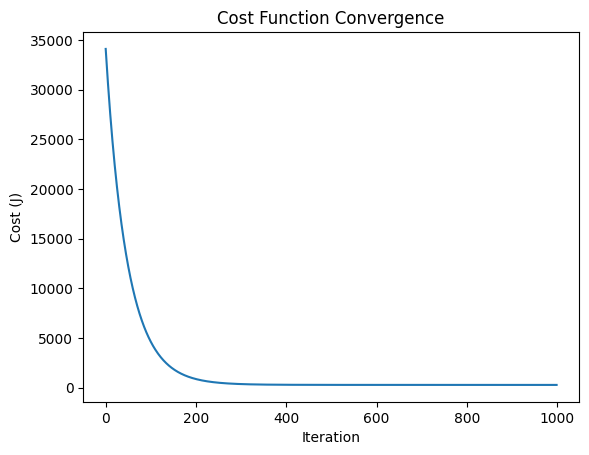

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "FuelConsumptionCo2.csv"
data = pd.read_csv(file_path)


features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']
target = 'CO2EMISSIONS'

X = data[features].values
y = data[target].values
m, n_features = X.shape


X = np.c_[np.ones(m), X]
n = X.shape[1]


X_normalized = X.copy()
for j in range(1, n):
    X_normalized[:, j] = (X[:, j] - np.mean(X[:, j])) / np.std(X[:, j])


theta = np.zeros(n)
alpha = 0.01
iterations = 1000


def compute_cost(X, y, theta):
    m = len(y)
    h = X.dot(theta)
    J = (1 / (2 * m)) * np.sum((h - y) ** 2)
    return J


def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        h = X.dot(theta)
        gradient = (1 / m) * X.T.dot(h - y)
        theta = theta - alpha * gradient
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return theta, cost_history


theta_optimal, cost_history = gradient_descent(X_normalized, y, theta, alpha, iterations)


print("\nOptimal theta:", theta_optimal)
print("Final cost:", cost_history[-1])


def predict(X_new, theta):
    return X_new.dot(theta)


example = np.array([1, 3.5, 6, 11.1])
example_normalized = example.copy()
for j in range(1, n):
    example_normalized[j] = (example[j] - np.mean(X[:, j])) / np.std(X[:, j])
prediction = predict(example_normalized, theta_optimal)
print("Predicted CO2 emissions for example:", prediction)


plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title("Cost Function Convergence")
plt.show()